# Single cell downstream analysis in R: ALS vs Wild-type controls

The overarching research question we aim to answer is: what cell type and gene expression changes drive motor neuron death in ALS? This notebook performs a comprehensive analysis of single cell data in R, focusing on pseudobulk differential expression and cell-cell communication inference using CellChat.

**Workflow:**
1.  **Environment Setup:** Install and load necessary R libraries.
2.  **Data Preparation:** Load Seurat objects and clean metadata.
3.  **Pseudobulk DE:** Robust differential expression analysis using DESeq2.
4.  **CellChat Analysis :** Inferring and comparing cell-cell communication networks focused on secreted signaling.

## 1.0 Environment Setup

We begin by installing the necessary Linux system libraries (required for Colab) and the R packages needed for the analysis. We then load the libraries into the session.

In [ ]:
# # ------------Skip this step for in-person events ---------
# # OPTIONAL - this installs all packages directly from the source code
# # useful if hoping to use most up-to-date package versions
# # It takes ~52 mins to run
# #
# # R packages are collections of functions written by the community that
# # extend R's capabilities. We install packages from three sources:
# #   - CRAN: the main R package repository (general-purpose tools)
# #   - Bioconductor (BiocManager): a repository specialized for
# #     bioinformatics tools like DESeq2
# #   - GitHub: for cutting-edge packages not yet on CRAN/Bioconductor,
# #     like CellChat and speckle
# # ---------------------------------------------------------
# # STEP 1: Install Linux System Libraries
# # Run each line separately if one fails
# # ---------------------------------------------------------
# system("apt-get update -qq", intern = TRUE)
# system("apt-get install -y libcurl4-openssl-dev libssl-dev libxml2-dev libgsl-dev libcairo2-dev libfontconfig1-dev libudunits2-dev libgmp-dev libmpfr-dev libxt-dev libhdf5-dev libblas-dev liblapack-dev gfortran build-essential libglpk-dev libfontconfig1-dev libfreetype6-dev libpng-dev libtiff5-dev libjpeg-dev", intern = TRUE)

# # Verify system libs installed (should see no errors)
# cat("System libraries installed\n")

# # ---------------------------------------------------------
# # STEP 2: Set Up BiocManager for R 4.6
# # ---------------------------------------------------------
# if (!require("remotes", quietly = TRUE)) install.packages("remotes")
# if (!require("devtools", quietly = TRUE)) install.packages("devtools")
# if (!require("BiocManager", quietly = TRUE)) install.packages("BiocManager")

# # Force Bioconductor 3.23 (required for R 4.6)
# BiocManager::install(version = "3.23", ask = FALSE, update = FALSE)

# # ---------------------------------------------------------
# # STEP 3: Install Bioconductor Packages
# # ---------------------------------------------------------
# BiocManager::install(
#  c("ComplexHeatmap", "Biobase", "BiocGenerics", "BiocNeighbors", "biomaRt", "DESeq2"),
#  update = FALSE,
#  ask = FALSE
# )

# # ---------------------------------------------------------
# # STEP 4: Install known problem CRAN packages from source first
# # ---------------------------------------------------------
# install.packages(c("units", "ape"), type = "source")
# install.packages("Rnanoflann", type = "source")

# # ---------------------------------------------------------
# # STEP 5: Install remaining CRAN packages
# # ---------------------------------------------------------
# install.packages(c(
#  "igraph", "ggplot2", "patchwork", "ggalluvial", "circlize",
#  "Seurat", "dplyr", "ggrepel", "googledrive", "tibble",
#  "enrichR", "tidyverse", "openxlsx", "NMF", "qs2"
# ))

# # ---------------------------------------------------------
# # STEP 6: Install GitHub Packages
# # ---------------------------------------------------------
# remotes::install_github("jinworks/CellChat")
# remotes::install_github("immunogenomics/presto")
# remotes::install_github("phipsonlab/speckle")
# remotes::install_github("bnprks/BPCells/r")

# # ---------------------------------------------------------
# # STEP 7: Verify installations
# # ---------------------------------------------------------
# packages <- c("Seurat", "CellChat", "DESeq2", "ComplexHeatmap",
#              "biomaRt", "tidyverse", "enrichR", "speckle", "qs2")

# results <- sapply(packages, function(pkg) {
#  tryCatch({
#    library(pkg, character.only = TRUE)
#    paste("OK:", packageVersion(pkg))
#  }, error = function(e) {
#    paste("FAILED:", conditionMessage(e))
#  })
# })

# print(as.data.frame(results))

In [ ]:
# system(paste0("cp -r ", .libPaths()[1]," ./R_packages"))
# system("tar -czvf ./R_packages.tar.gz ./R_packages")

In [ ]:
## ---------------------------------------------------------
## Download Pre-installed Libraries
## ---------------------------------------------------------
system("wget https://cf.10xgenomics.com/supp/cell-exp/workshop_tutorial_v2/R_packages.tar.gz")

# Move all pre-installed R packages to default R folder path
system("tar -xzvf ./R_packages.tar.gz -C /")
system(paste0("cp -r /R_packages/. ", .libPaths()[1]))

In [ ]:
## Some R libraries require system-level updates
## We execute those here
system("apt-get update -qq")
system("apt-get install -y libglpk40")

In [ ]:
## ---------------------------------------------------------
## Load Libraries
## ---------------------------------------------------------
suppressPackageStartupMessages({
  library(Seurat)
  library(CellChat)
  library(patchwork)
  library(ggplot2)
  library(dplyr)
  library(qs2)
  library(ggrepel)
  library(googledrive)
  library(DESeq2)
  library(tibble)
  library(ComplexHeatmap)
  library(IRdisplay)
  library(devtools)
  library(speckle)
  library(Matrix)
  library(BPCells)
})
print("Environment setup complete.")

## 2.0 Data Loading and Preparation

10x Cloud Analysis outputs a Seurat Object as a .qs file. A .qs file is a fast serialization file used in R, designed to save and load data objects (like data frames or lists) much faster than standard methods (github.com/qsbase/qs). We saved the .qs Seurat Object in our Google Drive, so will access it from there. First, mount the Google Drive so that we can access files in it directly. Then enter an authentication key - follow the instructions as the code progresses.

In this case, we used 10x Cloud Analysis to generate an integrated Seurat Object.

A Seurat object is a self-contained data structure that bundles together the gene expression count matrices, cell metadata, dimensionality reductions, and analysis results for an experiment. Think of it as a structured container that keeps all your data organized and linked.

To create a Seurat Object starting from a feature barcode matrix, see Seurat documentation [here](https://satijalab.org/seurat/articles/pbmc3k_tutorial.html).

In [ ]:
## ------------Skip this step for in-person events ---------
## Instructions for linking to personal gdrive directly and finding the needed file
#library(googledrive)
# --- 1. Authenticate and Download Data ---
#drive_auth()

## Find and download the Seurat object
#file_info <- drive_find(pattern = "integrated_seurat_object.qs2", n_max = 1)
#if (nrow(file_info) > 0) {
#  drive_download(as_id(file_info$id), path = "integrated_seurat_object.qs2", overwrite = TRUE)
#} else {
#  stop("File not found on Google Drive. Please check the filename.")
#}

## --- 2. Load and Annotate ---
#seurat_obj <- qs_read("integrated_seurat_object.qs2")
#DefaultAssay(seurat_obj) <- "SCT"

In [ ]:
##Upload data directly from s3
## This step takes ~1 min
## --- 1. Load .qs2 file from s3 ---
system("wget https://cf.10xgenomics.com/supp/cell-exp/workshop_tutorial_v2/integrated_seurat_object.qs2")

## --- 2. Load into a Seurat Object ---
seurat_obj <- qs_read("integrated_seurat_object.qs2")

In [ ]:
seurat_obj

🔍 Making Connections: what do the numbers "58467" and "82221" represent in the above text?

The summary text mentions that there are 2 assays in our object. Let's take a look at them.

In [ ]:
seurat_obj@assays

Each assay in a Seurat object stores a different representation of the gene expression data. The RNA assay contains the raw UMI counts, organized per sample. The SCT assay contains the normalized and variance-stabilized counts generated by SCTransform, which corrects for differences in sequencing depth across cells and samples.

Every Seurat Object should have some metadata. Let's see what that looks like.

In [ ]:
head(seurat_obj@meta.data)

In [ ]:
unique(seurat_obj@meta.data$sample)

Each row in the metadata table corresponds to a single cell, identified by its unique barcode (shown as row names). The columns describe properties of that cell, such as which sample it came from and how many genes were detected.

Looking at the metadata, we can see that we have sample information, but we do not have condition information. We need to specify which samples belong to which condition and add it into our metadata for downstream analysis.

In [ ]:
##Rename "sample" column to "samples" (this is required for analysis in later steps - one of the tools looks for a column named "samples" and does not recognize columns named "sample")
seurat_obj@meta.data$samples <- seurat_obj@meta.data$sample

In [ ]:
## Define sample groups - we need to know which cell came from which sample, and which sample from which condition,
##in order to perform our analyses
wt_samples <- c("WT_1_filtered", "WT_2_filtered", "WT_3_filtered")
sod1_samples <- c("SOD1_1_filtered", "SOD1_2_filtered", "SOD1_3_filtered")

## Add 'condition' metadata column
seurat_obj$condition <- case_when(
  seurat_obj$samples %in% wt_samples  ~ "WT",
  seurat_obj$samples %in% sod1_samples ~ "SOD1"
)

Next, we'll take a look at how many cells come from each sample.

In [ ]:
table(seurat_obj$samples, seurat_obj$condition)

🔍 Making Connections: How many cells are present per sample? Is the distribution roughly equal across samples? In a well-balanced experiment, we want similar cell numbers per sample to avoid composition artifacts in downstream analyses."

We manually annotated cell types in Loupe Browser and exported the results to a csv file. We will upload the CellType.csv information into our environment and add it to our Seurat object.

In [ ]:
## Load and Add Cell Types from CSV
##First load cell type annotations as a csv
system("wget https://cf.10xgenomics.com/supp/cell-exp/workshop_tutorial_v2/ManualCellTypes.csv")

##store the cell type annotations in a dataframe called "celltype_df"
celltype_df <- read.csv("ManualCellTypes.csv")
##Set the columns and rows of the dataframe
celltype_lookup <- setNames(celltype_df$Manual.Cell.Types, celltype_df$Barcode)
##Add a new metadata column to our seurat object called "cell type"
##Add cell type annotations to the new column by matching the barcodes in the dataframe to the Seurat object
seurat_obj$celltype <- celltype_lookup[colnames(seurat_obj)]

💡 Try it: Write a line of code to verify that your manual cell type annotations were added to the metadata. Hint: `head()` returns the first few rows of a table — you've already used it above!

Now that our cells are labeled by type and condition, we're ready to ask: do we observe differences in gene expression between SOD1 and WT within specific cell types?

## 3.0 Pseudobulk Differential Expression

Do we observe differences in specific genes or molecular pathways in SOD1 vs WT? To do this, we can test for differential expression between the SOD1 and WT conditions within each cell type. We aggregate counts to the sample level ("pseudobulk") to robustly identify differentially expressed genes (DEGs) using DESeq2. We will start with one cell type and edit the code to investigate others. To start, we will ask what are the differentially expressed genes between SOD1 and WT in microglia?

To aggregate our counts within each cell type, by sample, we'll need to add some additional metadata to our seurat object. In the next code block, we will add a "sample_celltype" column so that we can sum together the counts for all cells of a cell type in a given sample. Then, we actually sum together the counts using `AggregateExpression()` from Seurat. The final two steps of the setup are to pull out one cell type (in our case microglia) and clean up the metadata for the calculation.

In [ ]:
# @title ⚙️ Pseudobulk Setup (Steps 1-4)
# @markdown This cell prepares the pseudobulk count matrix for DESeq2.
# @markdown It: (1) creates a sample+celltype identifier, (2) aggregates
# @markdown counts across cells, (3) isolates microglia, and (4) aligns
# @markdown the metadata for DESeq2. Output: `microglia_counts` and `col_data`.

# --- Step 1: Create sample_celltype identifier ---
counts <- GetAssayData(seurat_obj, assay = "SCT", layer = "counts")
seurat_obj$sample_celltype <- paste(seurat_obj$sample, seurat_obj$celltype, sep = "|")

# --- Step 2: Aggregate counts to pseudobulk using BPCells (streaming, no indicator matrix) ---
groups <- factor(seurat_obj$sample_celltype)

# Write to disk once so BPCells streams from disk instead of holding the
# whole matrix in RAM. Skip this conversion if seurat_obj already stores
# counts as a BPCells-backed layer (Seurat v5) — just use GetAssayData() directly.
bpcells_dir <- tempfile("bpcells_counts_")
write_matrix_dir(as(counts, "IterableMatrix"), bpcells_dir)
counts_bp <- open_matrix_dir(bpcells_dir)

# Streams cells -> groups directly; no genes x cells intermediate, no
# genes x cells %*% cells x groups indicator multiply ever materializes
pseudobulk_counts <- pseudobulk_matrix(counts_bp, cell_groups = groups, method = "sum")
pseudobulk_counts <- as.matrix(pseudobulk_counts)  # safe to densify now — genes x ~30 groups, tiny

unlink(bpcells_dir, recursive = TRUE)  # tidy up disk usage

# --- Step 3: Isolate microglia columns ---
microglia_cols   <- grep("\\|Microglia$", colnames(pseudobulk_counts), value = TRUE)
microglia_counts <- pseudobulk_counts[, microglia_cols, drop = FALSE]
clean_samples    <- gsub("\\|Microglia$", "", microglia_cols)
colnames(microglia_counts) <- clean_samples

# --- Step 4: Prepare metadata for DESeq2 ---
col_data <- seurat_obj@meta.data %>%
  as_tibble() %>%
  select(sample, condition) %>%
  distinct() %>%
  filter(sample %in% clean_samples) %>%
  column_to_rownames("sample")

# Ensure column order matches row order in metadata (required by DESeq2)
microglia_counts <- microglia_counts[, rownames(col_data)]

message("✅ Pseudobulk setup complete. Ready to run DESeq2.")
message("   Samples: ", ncol(microglia_counts),
        " | Genes (before filtering): ", nrow(microglia_counts))

Let's take a quick look at what the pseudobulk matrix looks like. Each column is a sample and each value is the summed count for that gene across all microglia cells in that sample — these should be positive integers, much larger than what you'd see in a single cell.

In [ ]:
# Preview the pseudobulk count matrix and sample metadata
cat("=== Pseudobulk count matrix (first 5 genes, all samples) ===\n")
print(head(microglia_counts, 5))

cat("\n=== Sample metadata (condition assignments) ===\n")
print(col_data)

Now that our dataframe is cleaned up and well-annotated, we can actually run the differential expression analysis using `DESeqDataSetFromMatrix()` from the DESeq2 package. We will store the results in a "dds" object.

In [ ]:
## ---------------------------------------------------------
## Step 5: Run DESeq2
## --------------------------------------------------------
## Create the DESeq2 object
dds <- DESeqDataSetFromMatrix(
  countData = microglia_counts,
  colData   = col_data,
  design    = ~ condition              # We are testing based on 'condition' (SOD1 vs WT)
)

## Filter out genes with very low counts (less than 10 total across all samples)
dds <- dds[rowSums(counts(dds)) >= 10, ]

## Run the actual DESeq2 math
dds <- DESeq(dds)

## Extract the results, specifically comparing SOD1 to WT
res <- results(dds, contrast = c("condition", "SOD1", "WT"))


The analysis is complete and we will filter our results for significant genes with a padj < 0.05 and absolute log2 Fold-Change > 1.0. We will store these in a csv for easy export.

In [ ]:
## ---------------------------------------------------------
## Step 6: Filter and Save Significant DEGs
## ---------------------------------------------------------
## Convert to a data frame, filter for significance (padj < 0.05) and fold change
res_df <- as.data.frame(res) %>%
  rownames_to_column("gene") %>%
  filter(
    !is.na(padj),
    padj < 0.05, #   padj < 0.05  = adjusted p-value (corrects for multiple testing across ~24,000 genes)
    abs(log2FoldChange) > 2 #|log2FC| > 2 = at least a 2-fold change in expression between SOD1 and WT
  )


## Print a quick summary to the console so the student can see how many DEGs were found
message("Total significant DEGs in Microglia: ", nrow(res_df))

## Save the final results to a CSV file
write.csv(res_df, "Microglia_DEGs_significant.csv", row.names = FALSE)

We have a nice summary of our results, but if we want to publish these results, it would be nice to summarize them visually in a plot. We will convert the data to a matrix in the next code block for easy plotting.

In [ ]:
## ---------------------------------------------------------
## Step 7: Visualize DEGs for Microglia
## ---------------------------------------------------------
## First, calculate the total number of up-regulated and down-regulated genes
up_count <- sum(res_df$log2FoldChange > 2)
down_count <- sum(res_df$log2FoldChange < -2)

## Create a simple vector of our two numbers
counts_vector <- c(up_count, down_count)

## Adjust the left margin to make room for our new bar labels
## par(mar = c(Bottom, Left, Top, Right))
par(mar = c(5, 8, 4, 2))

## Set plot size (if using Jupyter/IRkernel)
options(repr.plot.width = 7, repr.plot.height = 4)

## Create the horizontal barplot
barplot(counts_vector,
        names.arg = c("Up in SOD1", "Down in SOD1"), # Labels next to each bar
        horiz = TRUE,
        las = 1,                                     # Forces the labels to be horizontal
        col = c("orange", "lightblue"),
        xlab = "Number of DEGs",
        main = "Differentially Expressed Genes in Microglia")

💡 Try it: Can you adapt the code blocks starting from Step 3 to identify DEGs for a different cell type, such as Astrocytes or Neurons? Hint: start from step 3 of this section.

---



### ✅ Section 3.0 Summary:
We found 654 significantly differentially expressed genes in microglia between SOD1 and WT mice. More genes are upregulated than downregulated, suggesting microglia are becoming more transcriptionally active in the disease state. This sets up our next question: are these activated microglia changing how they communicate with other cell types?

### Enrichment of DEGs using Enrichr

Enrichment analysis is a powerful way to make sense of differential gene expression results. Enrichr is a user-friendly, web-based gene set enrichment analysis tool that helps us interpret lists of genes by identifying biological pathways, molecular functions, transcription factors, diseases, and other functional categories that are overrepresented. It integrates a large collection of curated gene set libraries (such as GO, KEGG, and Reactome) and applies statistical tests to determine whether specific biological themes are significantly enriched in a gene list.

We use Enrichr to move beyond individual differentially expressed genes and gain higher-level biological insight—such as identifying affected pathways or regulatory mechanisms—making our results more interpretable and biologically meaningful.

Navigate to the "Files" tab of the panel on the left-hand side of this notebook. You should see a file called "Microglia_DEGs_significant.csv". Download and open it - you will see the differential expression results that we just generated for Microglia.

In this csv file, we have all significant genes using an adjusted p-value threshold of 0.05 and an absolute log2fc of 2.0. It has both upregulated and downregulated genes.

Next, we will take all upregulated genes. Because the csv has both upregulated and downregulated genes, we need to filter it. Use "Sort & Filter" in Excel to filter out negative log2fc values. (Alternatively, you can filter in R using `filter(res_df, log2FoldChange > 0)` and write the upregulated genes to a separate CSV.) Next, copy the resulting gene list. There should be 815 genes in total.

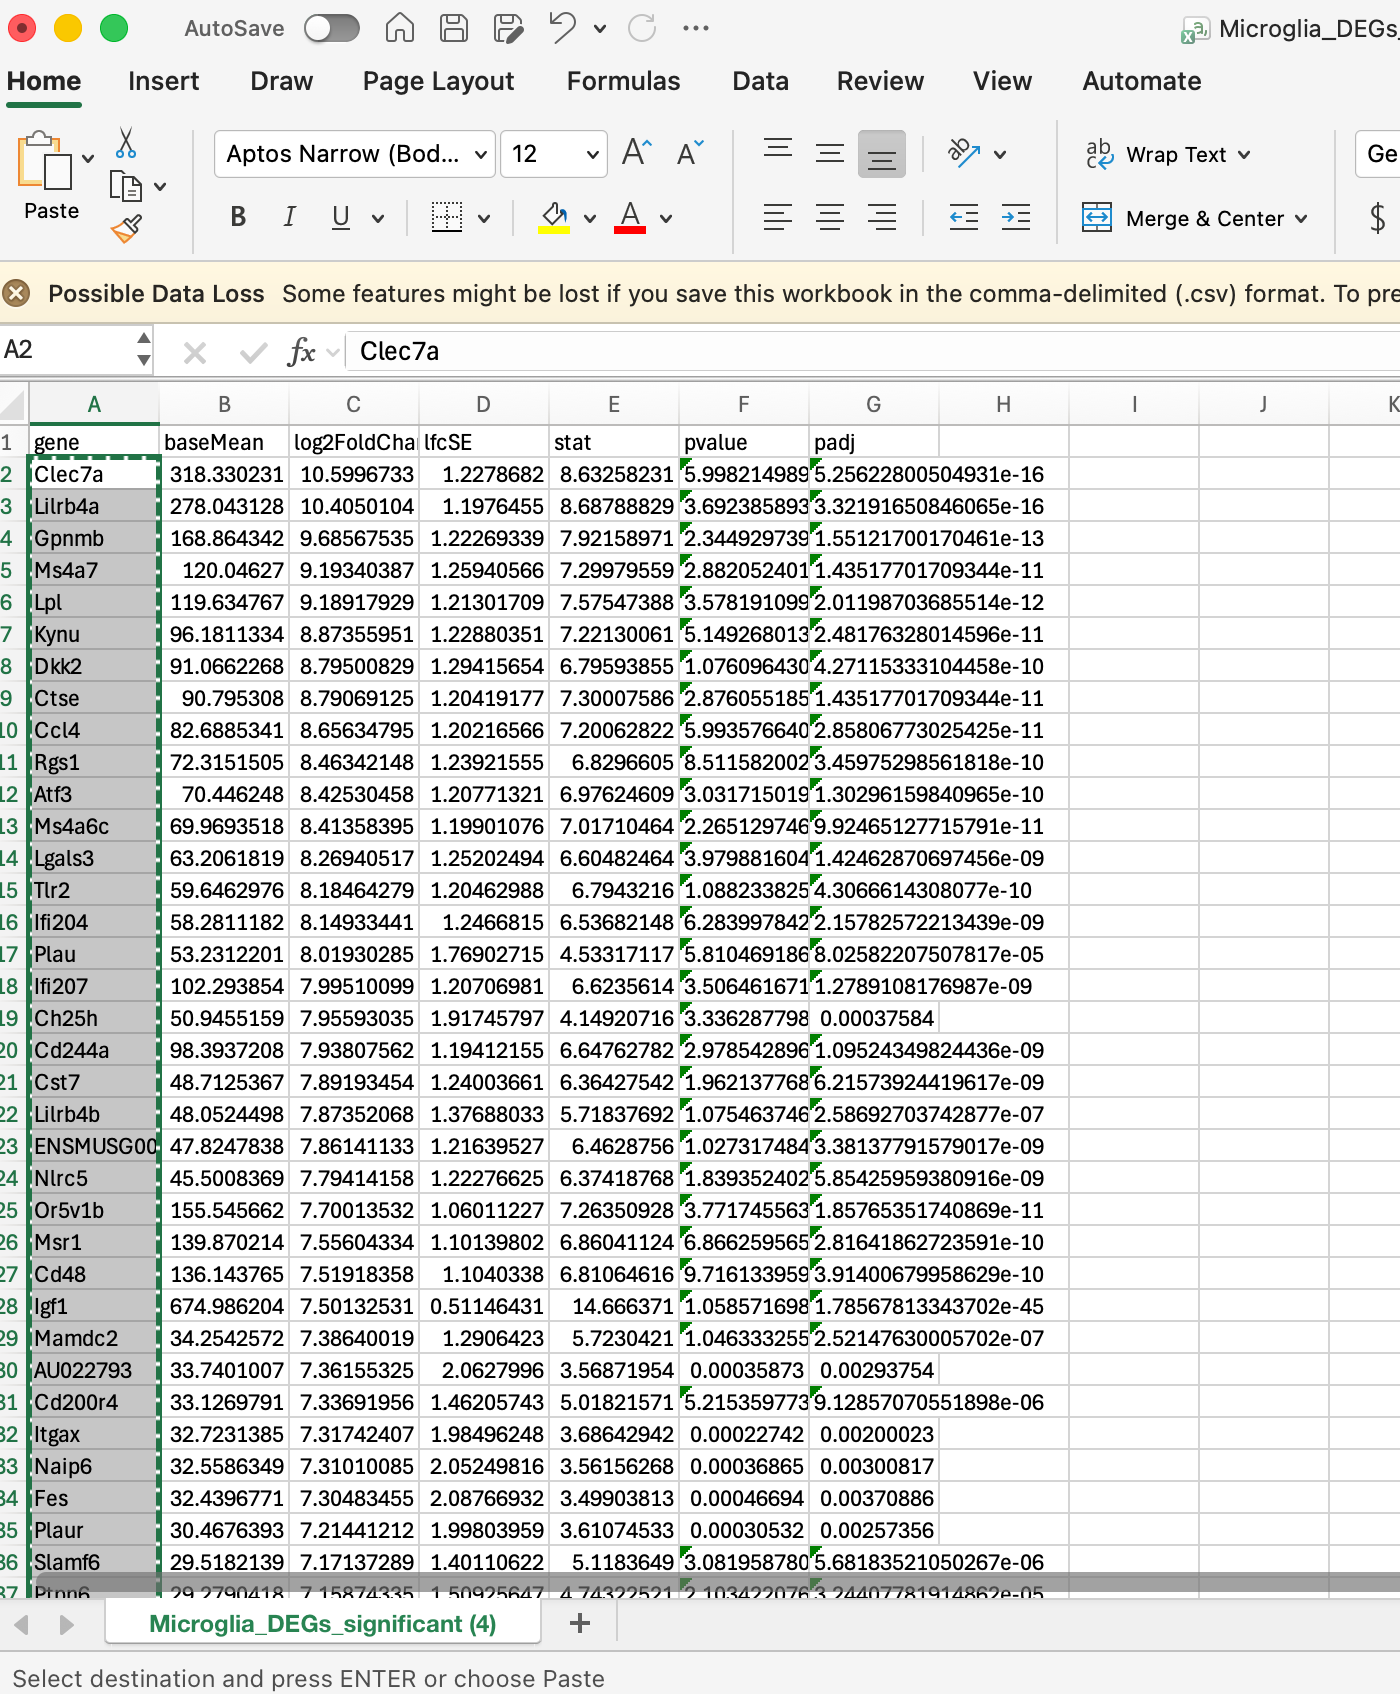

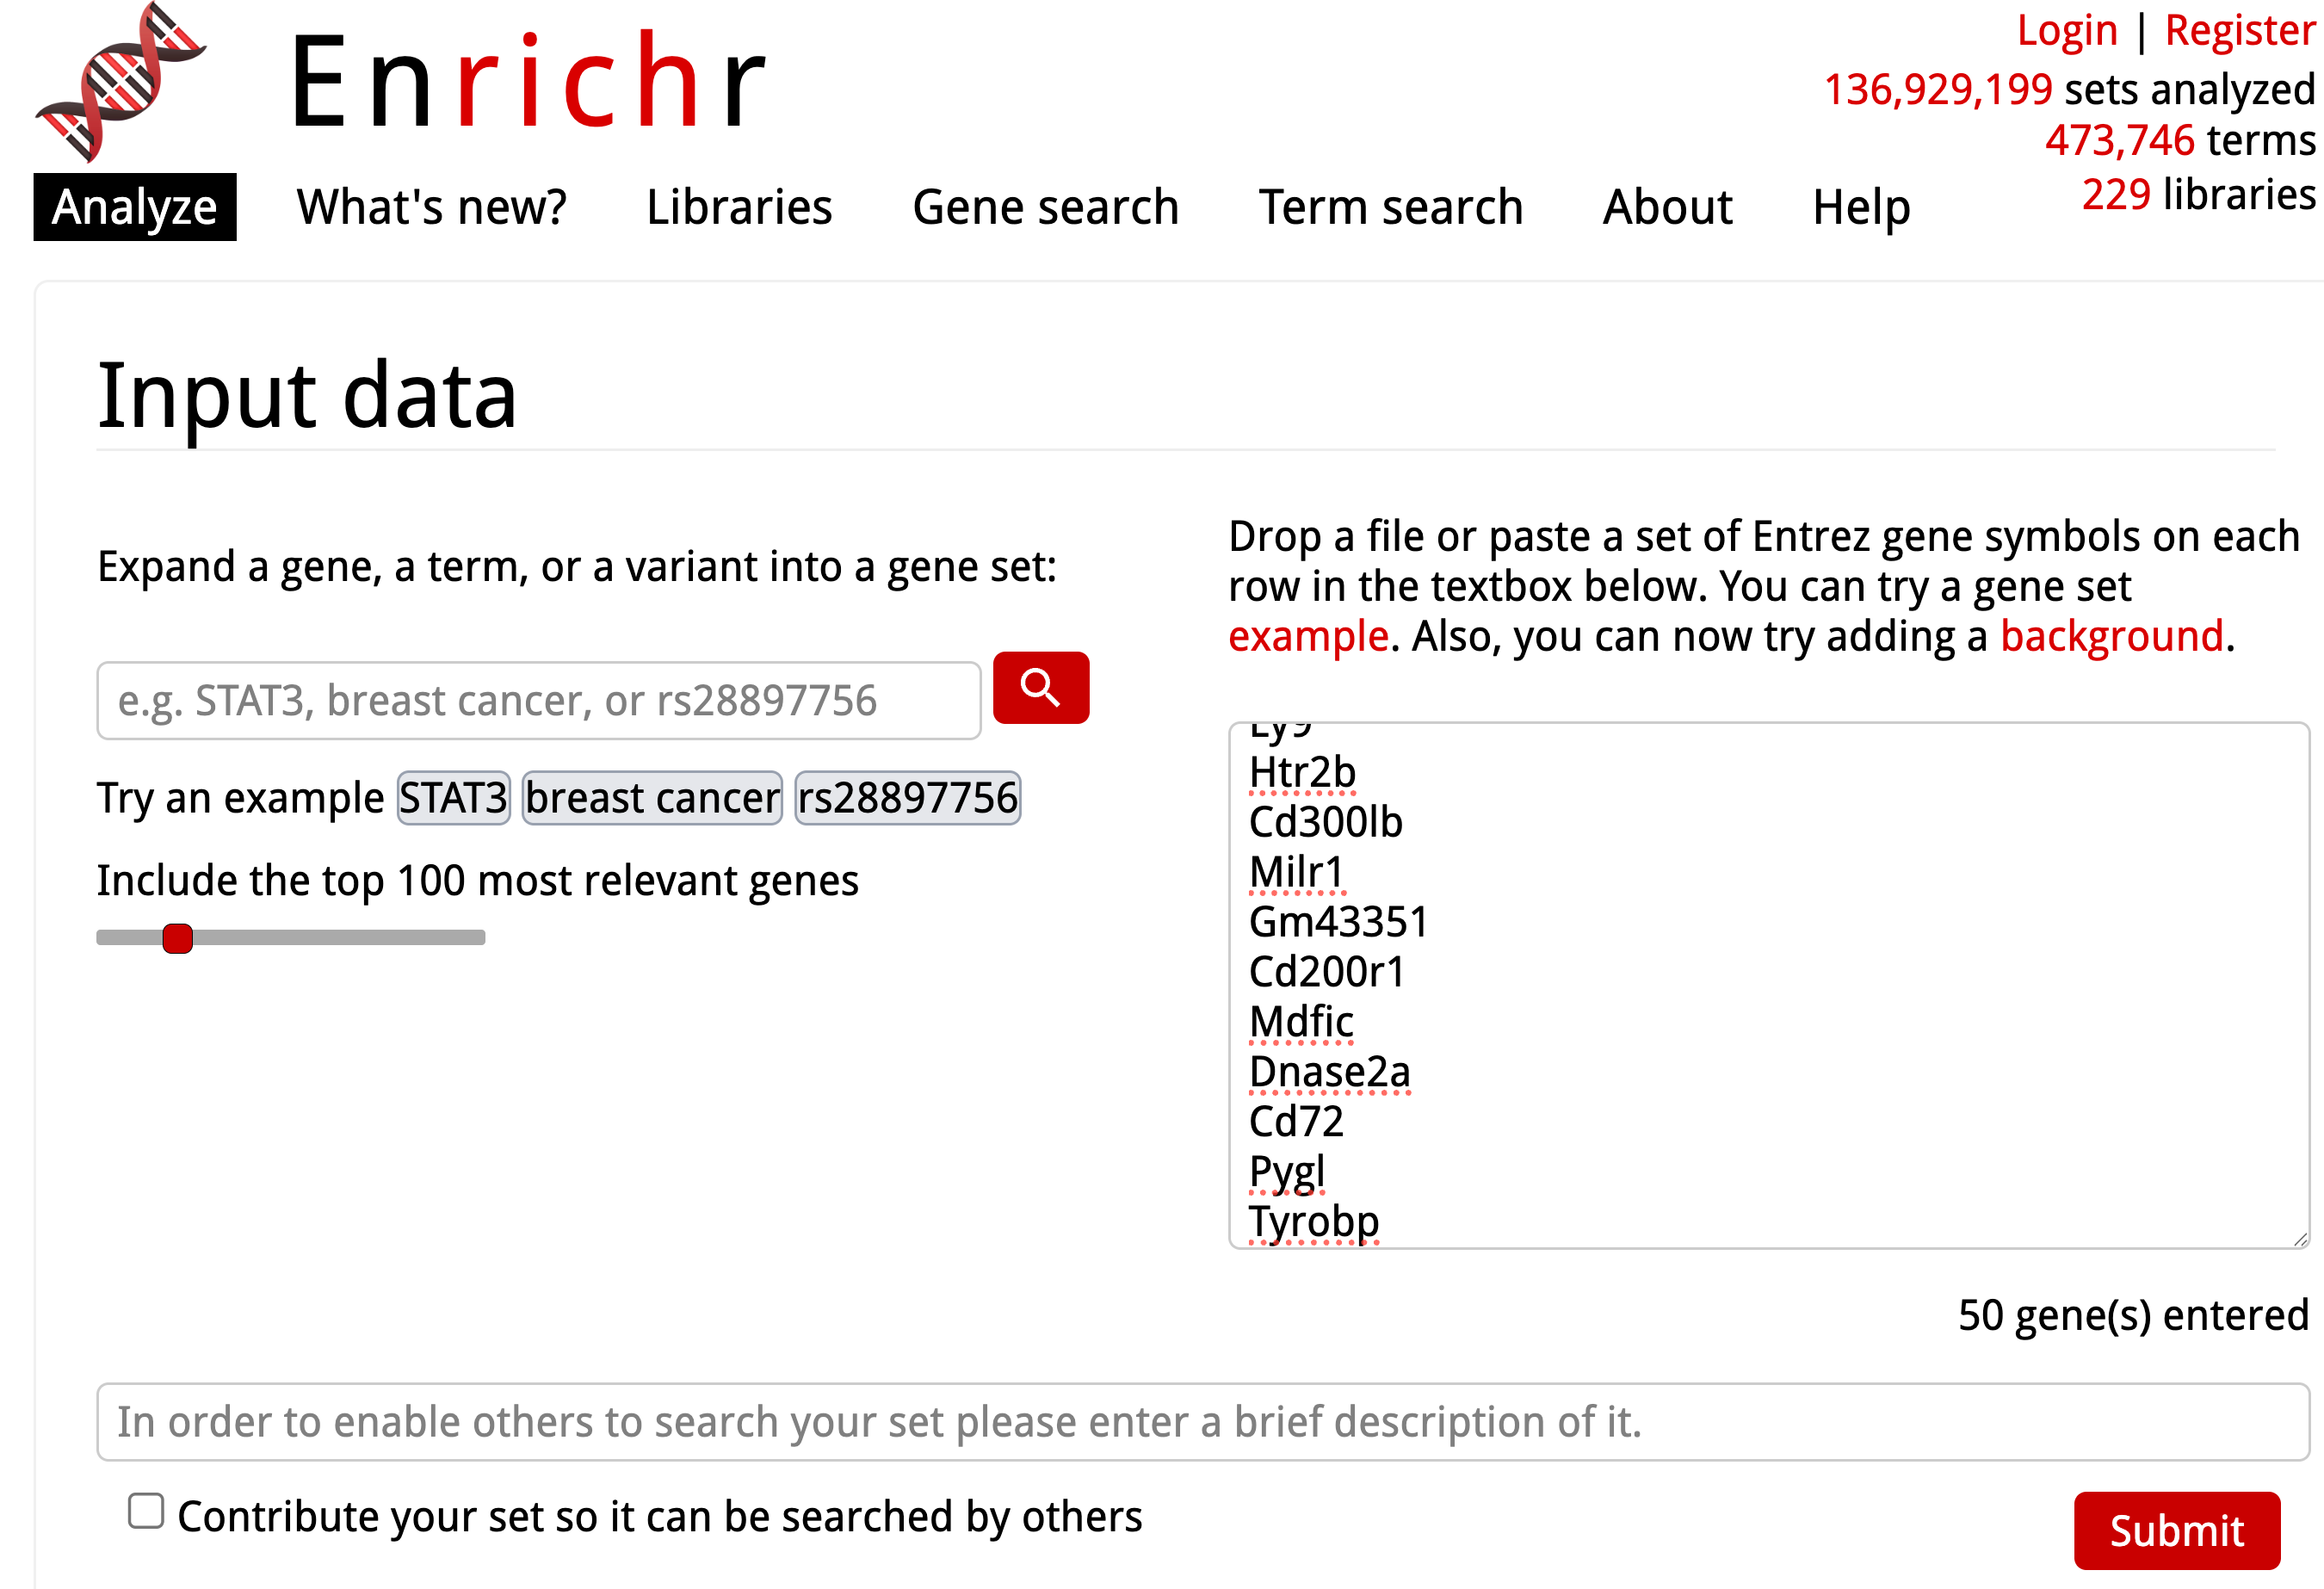

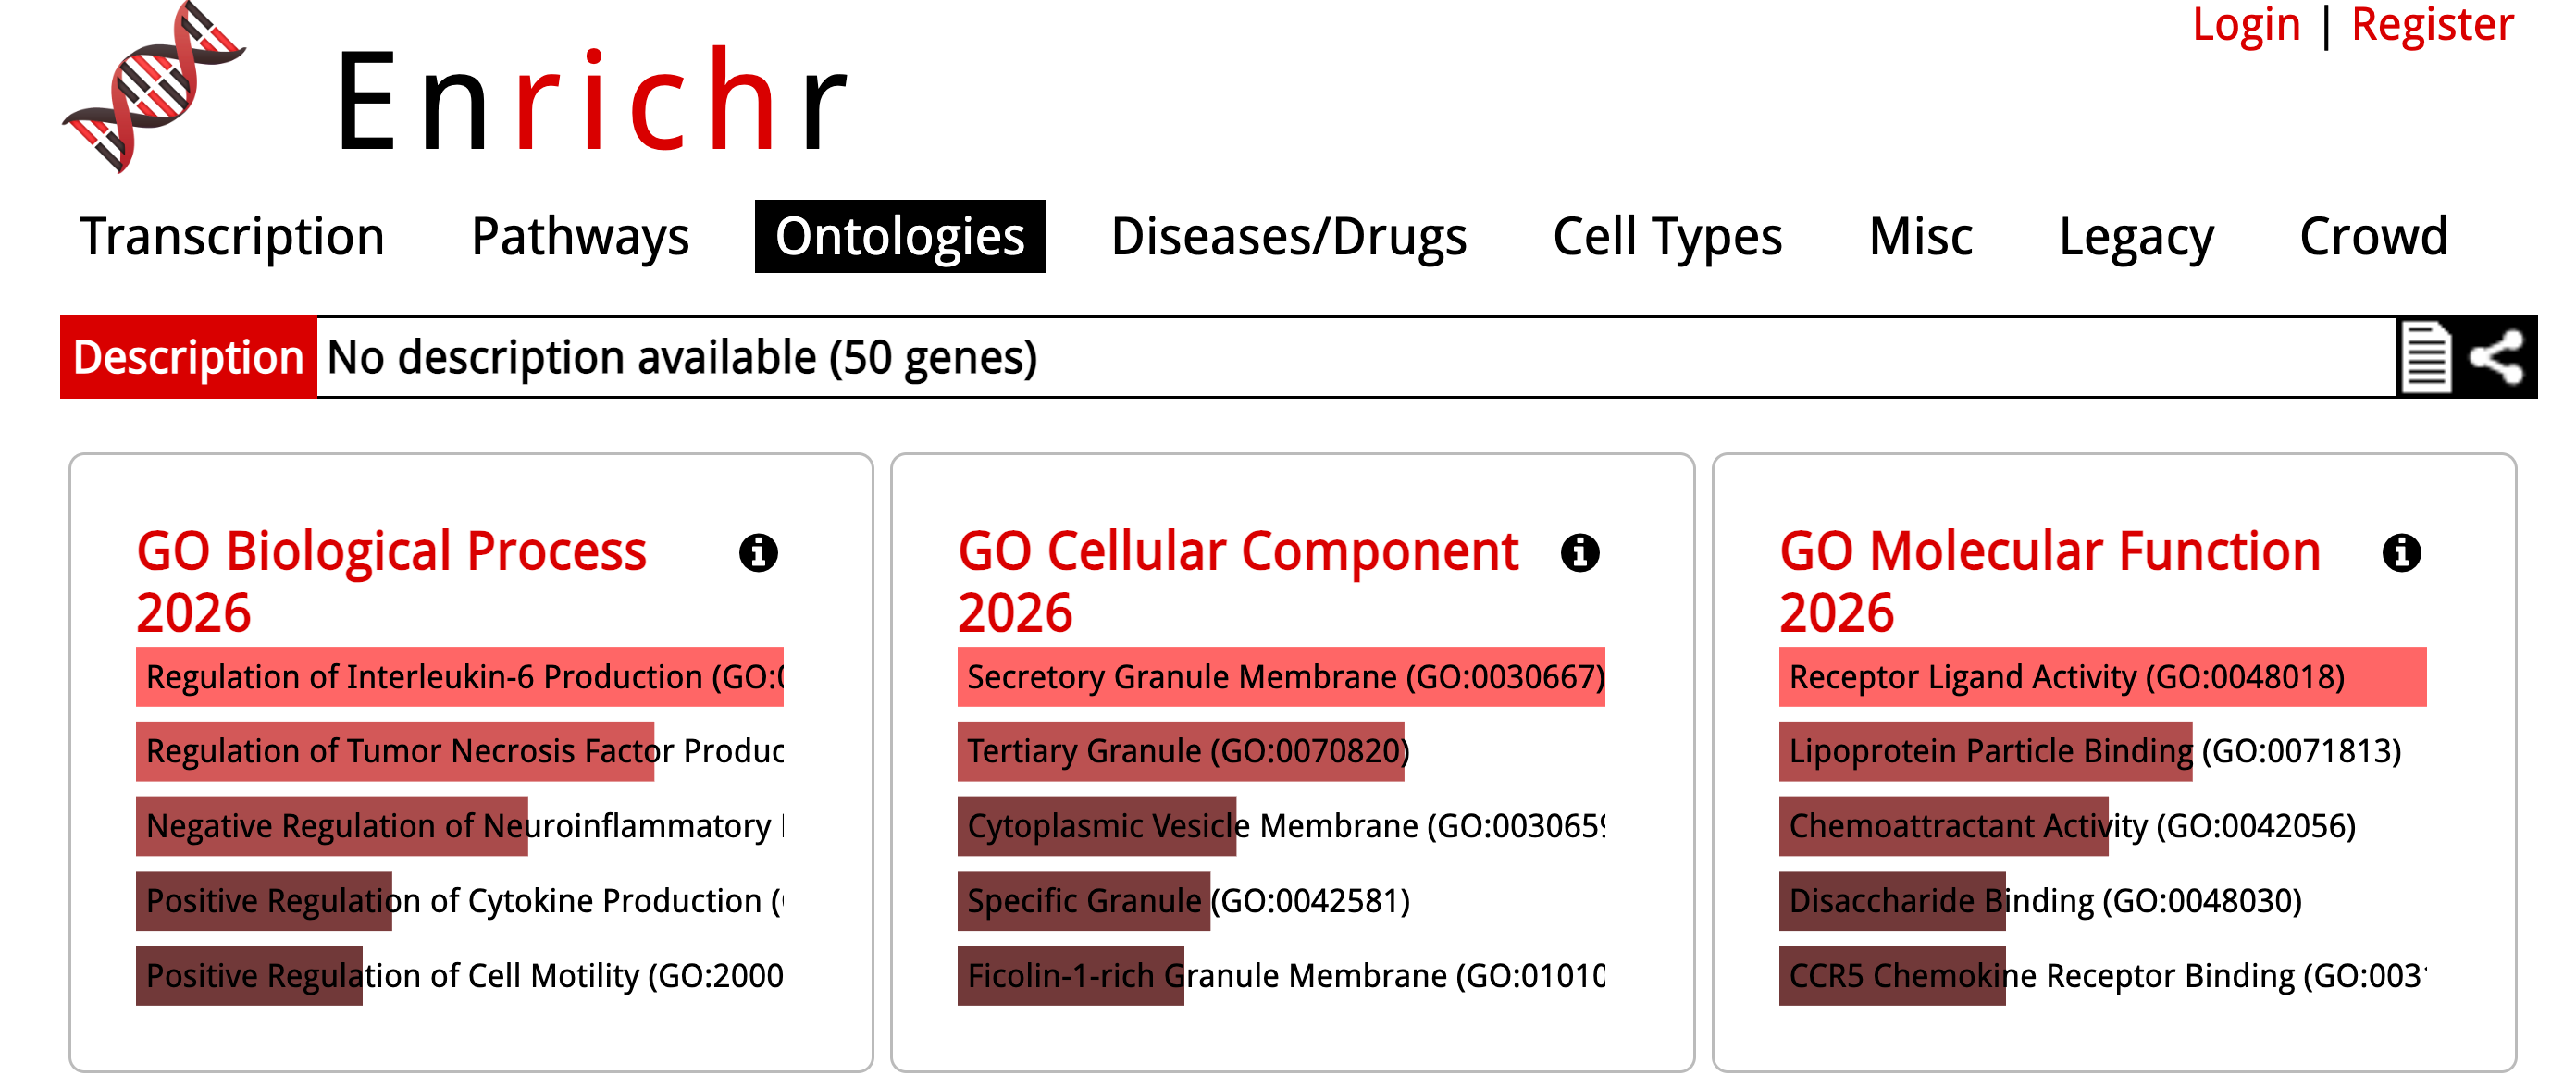

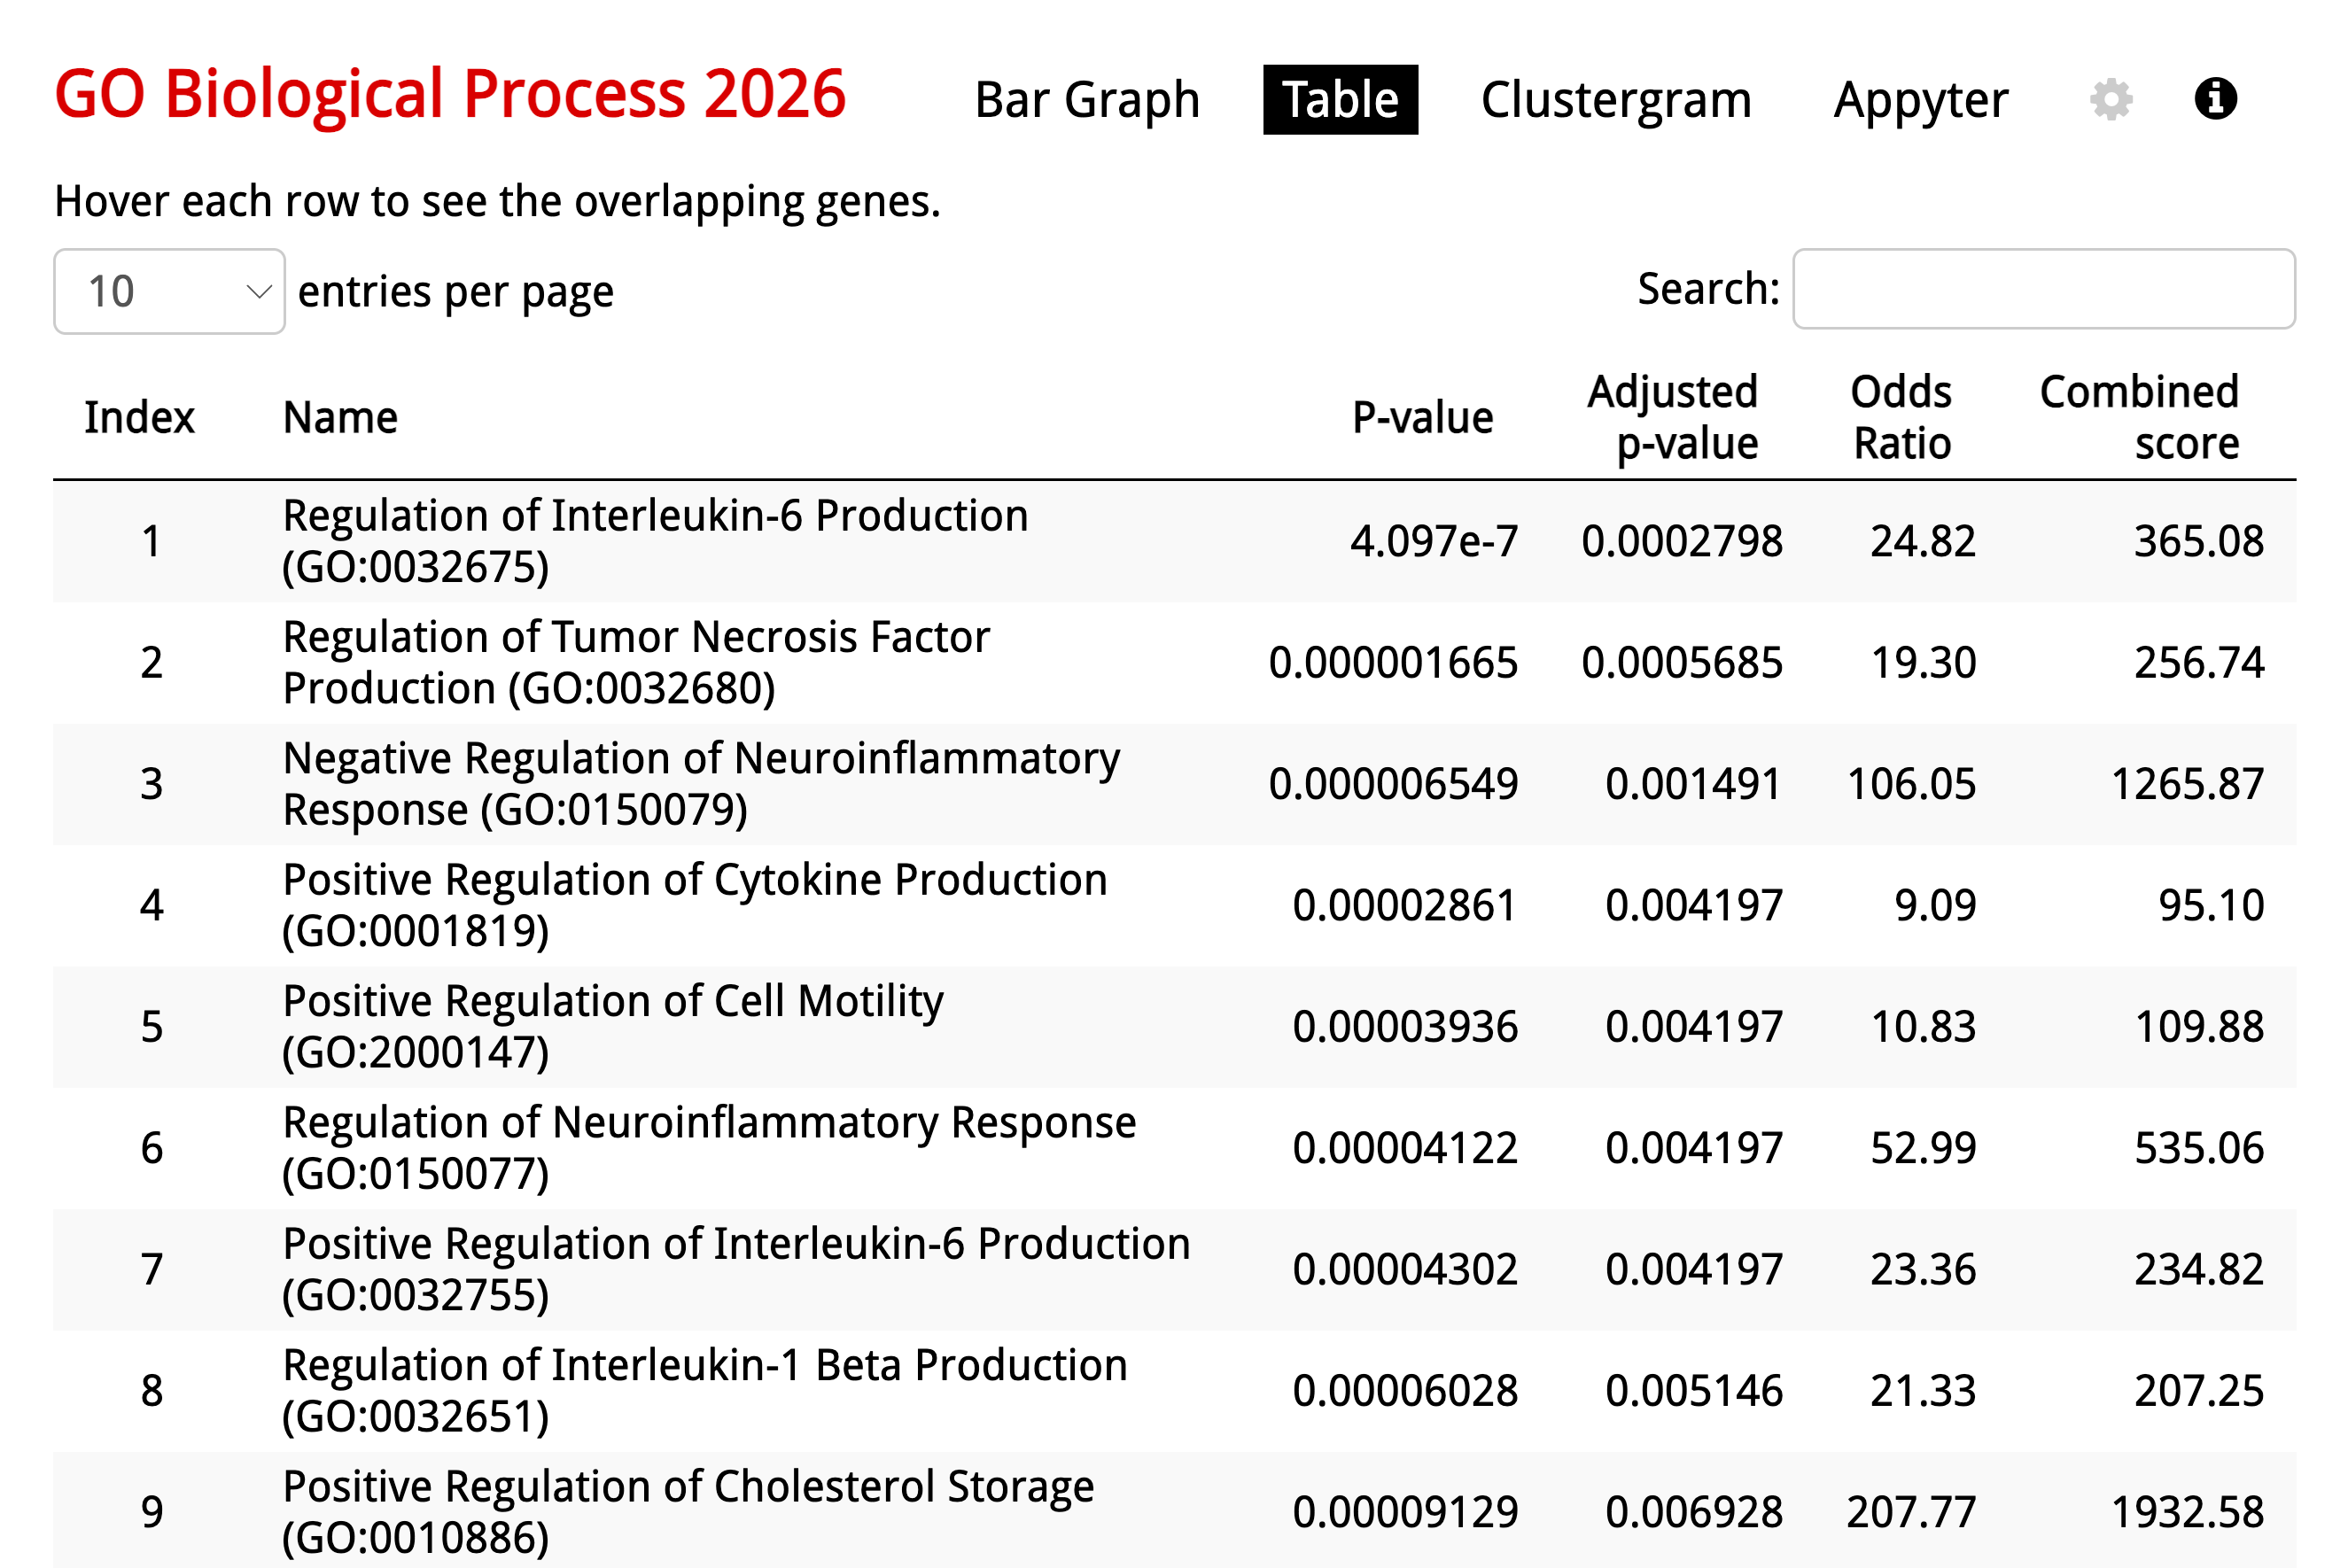

Interpretation: The tops pathway enriched in upregulated genes of SOD1 Microglia are Regulation of IL-6 Production, Regulation of Tumor Necrosis Factor, Positive Regulation of Cytokine Production. This suggests a transition of these Microglia to a reactive, pro-inflammatory state. Now that we know how microglia change themselves, our next question is how their functional state interacts with other cell types in the spinal cord. We will use cell-cell interaction analysis to map the specific signaling alterations occurring between these populations in the SOD1 condition.

## 4.0 Cell-Cell Communication (CellChat) - Secreted Signaling

Using cell type composition analysis and studying enrichment of DEGs in our cell types, we were able to identify some fundamental shifts in the cell type heterogeneity and gene expression in the SOD1 condition. What we are interested in studying now is how communication between cell types changes in the disease condition. To do this, we will use [CellChat](https://github.com/jinworks/CellChat), a tool that infers interactions between cell types using single cell gene expression information. In the next section, we infer cell-cell communication networks for each condition, WT and SOD1, and merge them to identify signaling changes.


CellChat identifies cell-cell interactions by searching for co-expression of known ligand-receptor pairs across cell types. For each condition (WT and SOD1), we: (1) subset the data, (2) identify overexpressed ligands and receptors, (3) compute communication probabilities using a statistical model, and (4) summarize interactions at the pathway level. We then merge the two objects to enable direct comparison.

**Skip to: "⚙️ Load Pre-computed CellChat Object" if you are running the free version of Google Co-Lab (12GB RAM). The next four steps require >12GB RAM and will cause a session crash in the free tier.**

In [ ]:
# ## SKIP this code block and next 3 if running on free version of Google Co-Lab (12GB RAM)
# ## This code block takes ~12mins with CPU
# ## --- 1. Setup & Database ---
# DefaultAssay(seurat_obj) <- "SCT" #CellChat requires normalized count data as input, so we specify the SCT slot
# PrepSCTFindMarkers(seurat_obj) #During SCT, data were normalized within samples, making the library sizes uncomparable. This step uses the minimum of median UMI as the sequencing depth covariate to correct for this
# ## We'll put both of the CellChat objects for each condition into a list for easier comparison
# CellChatDB.use <- subsetDB(CellChatDB.mouse, search = "Secreted Signaling") #Specify the database to use for the analysis - we will use Secreted Signaling

# ## --- 2. Process "WT" Condition ---
# ## This step takes ~6min with v5e1 TPU
# message("Processing: WT") #Print out a message to let us know which object is being processed
# seurat_wt <- subset(seurat_obj, subset = condition == "WT") #Subset our merged seurat object based on condition
# cc_wt <- createCellChat(object = seurat_wt, group.by = "celltype") #Create the CellChat object called "cc_wt"
# cc_wt@DB <- CellChatDB.use #Specify the database to use for L-R interactions

# cc_wt <- subsetData(cc_wt)  #Subset the data to only include genes in the cellchat database
# cc_wt <- identifyOverExpressedGenes(cc_wt) #First step identifies overexpressed genes with a differential expression test
# cc_wt <- identifyOverExpressedInteractions(cc_wt) #Next compares against the L-R database and performs a statistical test
# cc_wt <- computeCommunProb(cc_wt, raw.use = TRUE, type = "triMean") #Calculate the communication probability between cells
# cc_wt <- filterCommunication(cc_wt, min.cells = 10) #Filter out interactions identified in fewer than 10 cells
# cc_wt <- computeCommunProbPathway(cc_wt) #Compute the communication probability on signaling pathway level by summarizing all related ligands/receptors
# cc_wt <- aggregateNet(cc_wt)  #Calculate the aggregated network by counting the number of links or summarizing the communication probability
# cc_wt <- netAnalysis_computeCentrality(cc_wt, slot.name = "netP") #Compute the network centrality scores allowing identification of dominant senders, receivers, mediators and influencers in all inferred communication networks



In [ ]:
# ## --- 3. Process "SOD1" Condition (using same code as above) ---
# #This step takes ~6min with CPU
# message("Processing: SOD1") #Print out a message to let us know which object is being processed
# seurat_sod1 <- subset(seurat_obj, subset = condition == "SOD1") #Subset our merged seurat object based on condition
# cc_sod1 <- createCellChat(object = seurat_sod1, group.by = "celltype") #Create the CellChat object called "cc_sod1"
# cc_sod1@DB <- CellChatDB.use #Specify the database to use for L-R interactions

# cc_sod1 <- subsetData(cc_sod1)  #Subset the data to only include genes in the cellchat database
# cc_sod1 <- identifyOverExpressedGenes(cc_sod1) #First step identifies overexpressed genes with a differential expression test
# cc_sod1 <- identifyOverExpressedInteractions(cc_sod1) #Next compares against the L-R database and performs a statistical test
# cc_sod1 <- computeCommunProb(cc_sod1, raw.use = TRUE, type = "triMean") #Calculate the communication probability between cells
# cc_sod1 <- filterCommunication(cc_sod1, min.cells = 10) #Filter out interactions identified in fewer than 10 cells
# cc_sod1 <- computeCommunProbPathway(cc_sod1) #Compute the communication probability on signaling pathway level by summarizing all related ligands/receptors
# cc_sod1 <- aggregateNet(cc_sod1)  #Calculate the aggregated network by counting the number of links or summarizing the communication probability
# cc_sod1 <- netAnalysis_computeCentrality(cc_sod1, slot.name = "netP") #Compute the network centrality scores allowing identification of dominant senders, receivers, mediators and influencers in all inferred communication networks



In [ ]:
# ## --- 4. Merge for Comparison ---
# ## We manually combine them into a list so mergeCellChat can handle them
# cellchat_list <- list(WT = cc_wt, SOD1 = cc_sod1)
# cellchat_merged <- mergeCellChat(cellchat_list, add.names = names(cellchat_list))

Recall our overarching question: what drives motor neuron death in ALS? To answer this, we need to understand not just what changes within each cell type, but how cells are communicating with one another. The merged CellChat object we create here will let us directly compare the signaling landscape between WT and SOD1.

Building the CellChat objects requires running the full signaling inference pipeline separately on WT and SOD1 cells, which takes approximately 15–20 minutes. We have pre-computed this for you. The cell below loads the merged CellChat object directly from Google Drive so we can jump straight to exploring the results.
For reference, the full processing code is preserved in the collapsed cells above — everything needed to reproduce this from scratch on your own data.

In [ ]:
## Save the merged cellchat object as a .qs file for quick loading and usage later on
# qs_save(cellchat_merged, "cellchat_merged.qs2")

# message("✅ Saved cellchat_merged.qs to: ", getwd())
# message("   File size: ",
#         round(file.info("cellchat_merged.qs2")$size / 1e6, 1), " MB")

In [ ]:
# @title ⚙️ Load Pre-computed CellChat Object — Run this cell to get started
# @markdown Downloads the pre-built merged CellChat object from Google Drive.
# @markdown This replaces ~20 min of compute time. Output: `cellchat_merged`

# --- Option A: Load via gdown (fastest, no authentication needed) ---
# Replace the ID below with your own file ID from the Google Drive share link
system("wget https://cf.10xgenomics.com/supp/cell-exp/workshop_tutorial_v2/cellchat_merged.qs2")

# --- Load the object ---
cellchat_merged <- qs_read("cellchat_merged.qs2")

### Visualization: Overall assessment of number and strength of signaling interactions

CellChat employs a top-down approach, i.e., starting with the big picture and then refining it in a greater detail on the signaling mechanisms, to identify signaling changes at different levels, including altered interactions, cell populations, signaling pathways and ligand-receptor pairs. First, CellChat starts with a big picture to answer the following questions:

* Whether the cell-cell communication is enhanced or not

* The interaction between which cell types is significantly changed

* How the major sources and targets change from one condition to another

In [ ]:
## First we look at the raw number and strength of interactions calculated during our analysis
## Set the plot size (Width, Height) in inches
options(repr.plot.width = 12, repr.plot.height = 6)

## Compare Total Interactions
p1 <- compareInteractions(cellchat_merged, show.legend = T, group = c("WT","SOD1")) +
      theme(text = element_text(size = 14)) # Tip: Adjust the size = 18 value below to make text larger or smaller.

p2 <- compareInteractions(cellchat_merged, show.legend = T, group = c("WT","SOD1"), measure = "weight") +
      theme(text = element_text(size = 14))

print(p1 + p2)

Next, we take a look at the differences at the cell type level - interactions are changing in which cell types?

In [ ]:
##For all comparisons we are looking at SOD1-WT, so
##positive values indicate greater or stronger in SOD1
##while negative values indicate fewer or weaker in SOD1.

## Set the plot size (Width, Height) in inches
options(repr.plot.width = 12, repr.plot.height = 12)

## Plot the difference in number of interactions by cell type
ht <- netVisual_heatmap(cellchat_merged,
                        measure = "count",
                        title.name = "Differential Interactions (SOD1 - WT)",
                        font.size = 14)
ComplexHeatmap::draw(ht)

Based on this plot, we can see that Microglia and Meninges are sending and receiving more signals in the SOD1 condition compared to WT. Astrocytes are sending more signals to these two cell types in the SOD1 condition compared to WT. What could this mean in relation to the biology of ALS?

💡 Try it: Can you edit the code block above to visualize the net difference in interaction strength rather than number?

We can see that there are major differences in the number and strength of interactions. There are more and stronger interactions in the SOD1 condition compared to the WT. Next we ask: which signaling pathways are altered in SOD1 vs WT?


In [ ]:
## Compare the overall information flow of each signaling pathway or ligand-receptor pair
options(repr.plot.width = 16, repr.plot.height = 8)
gg1 <- rankNet(cellchat_merged, mode = "comparison", measure = "weight", sources.use = NULL, targets.use = NULL, stacked = T, do.stat = TRUE)
gg2 <- rankNet(cellchat_merged, mode = "comparison", measure = "weight", sources.use = NULL, targets.use = NULL, stacked = F, do.stat = TRUE)
gg1 + gg2

🔍 Making Connections:  Do you recognize any signaling pathways? What do you know about them?

### Interpretation

The pathways enriched in the SOD1 condition (teal) are classic markers of neuroinflammation and reactive gliosis.

* SPP1 (Osteopontin): The plot shows this as strongly biased toward SOD1. SPP1 is a major marker of "Disease Associated Microglia" (DAM) and reactive astrocytes. Its levels correlate with disease severity and fibrosis in ALS spinal cords.

* COMPLEMENT: The complement cascade (C3, C1q) drives synaptic pruning and neuroinflammation. In SOD1 mice, complement is upregulated early and marks synapses for destruction by microglia.

* CSF: Colony-stimulating factor (CSF) signaling is the primary regulator of microglial survival, proliferation, and differentiation in the central nervous system.

*Note that these are inferred interactions based on gene expression and known biology. This is not a direct measurement of signaling interactions.*


### Visualization: Identify specific cell types and signaling pathways that drive their shifts

Now that we have a general understanding of the differences in cell-cell communication between SOD1 and WT, we can probe further to identify which cell types are driving these differences and what specific pathways in each cell type are altered.

From the previous section, we identified increases in general signaling in the SOD1 condition. Looking at the signaling pathways that are enriched in the SOD1 condition, we identified several pathways that implicate Microglia as a critical hub of activity. Our heatmaps showing which cell types are sending and receiving signals support this hypothesis.

To investigate which signaling pathways in Microglia are driving the shift from few to many signals, we will plot the specific pathways and how they are shifting in Microglia.

In [ ]:
## Set the plot size (Width, Height) in inches
options(repr.plot.width = 18, repr.plot.height = 8)

## Bubble Plots (Increased vs Decreased)
## Here we are setting the "sources" and "targets" as Microglia vs all others:
p_inc <- netVisual_bubble(cellchat_merged, sources.use = c(6), targets.use = c(1:10), comparison = c(1, 2), max.dataset = 2,
                          title.name = "Increased in SOD1", angle.x = 45, remove.isolate = T)
p_dec <- netVisual_bubble(cellchat_merged, sources.use = c(6), targets.use = c(1:10), comparison = c(1, 2), max.dataset = 1,
                          title.name = "Decreased in SOD1", angle.x = 45, remove.isolate = T)
print(p_inc + p_dec)

Understanding the Axes
* Y-axis (Vertical): Lists specific Ligand-Receptor pairs (e.g., *Spp1 - Cd44*). The
first name is the "signal" sent, and the second is the "antenna" receiving it.
* X-axis (Horizontal): Shows the (Source $\rightarrow$ Target) cell types. Note the color coding: Red labels represent Wild Type (WT) and Blue labels represent SOD1.
* Bubble Color: Represents the Communication Probability (strength). Red is high/strong; blue is low/weak.
* Bubble Presence: Represents the L-R pairs with a p-value <0.01 (statistical significance).

Our cell-cell communication analysis shows a coordinated transition to reactive, inflammatory signaling in Microglia. Specifically, we see overwhelming Spp1, which reflects the transition of Microglia into a highly active, inflammatory state characteristic of late-stage ALS. Spp1 is a hallmark of Disease-Associated Microglia (DAM). In ALS, its upregulation is associated with a pro-inflammatory phenotype and microglial activation. Using the plot above, we are able to identify the specific ligand-receptor pairs that are increased in Microglia.

We can see which cell types are receiving these SPP1 signals from Microglia in the previous plot, but it is not easy to see. Next, we will plot the SPP1 pathway interactions by cell type to get a clearer picture of what this pathway looks like in the WT condition versus the SOD1 condition.

In [ ]:
# ## This code block will only work if you generated the CellChat object in the script rather than loading the pre-generated one
# ## Look at one pathway more closely in both objects
# ## Circle plot
# pathways.show <- c("SPP1")

# ## 1. Setup the plotting area
# par(mfrow = c(1,2), xpd=TRUE)

# ## 2. Loop through the objects
# for (i in 1:length(cellchat_list)) {

#   ## Retrieve available pathways to prevent errors
#   available_pathways <- cellchat_list[[i]]@netP$pathways

#   ## CHECK: Is the pathway present in this object?
#   if (pathways.show %in% available_pathways) {

#     ## If YES: Plot with auto-scaling
#     netVisual_aggregate(cellchat_list[[i]],
#                         signaling = pathways.show,
#                         layout = "circle",
#                         edge.weight.max = NULL,
#                         edge.width.max = 5,     # Controls the thickness of the strongest line
#                         signaling.name = paste(pathways.show, names(cellchat_list)[i]),
#                         arrow.size = 0.5)

#   } else {

#     ## If NO: Plot an empty placeholder
#     ## The plotting function will error out if the pathway was not identified in a condition at all
#     ## We added this for loop so that instead of erroring out, it will display "No significant interactions"
#     plot(1, type="n", axes=FALSE, xlab="", ylab="",
#          main = paste(pathways.show, names(cellchat_list)[i]))
#     text(1, 1, "No significant interactions\ndetected", cex = 1.2, col = "grey")
#   }
# }

In the WT condition, SPP1 signaling is sparse, primarily originating from Meninges. In the SOD1 condition, there is a surge of SPP1 activity from Microglia: Microglia send intense signals back to themselves (autocrine) and to several other cell types in the spinal cord, including OPCs, Pericytes, Astrocytes, and CSF Neurons.

SPP1 (Osteopontin) is a hallmark of "disease-associated" glia. This confirms that the increased glial populations are actively secreting pro-inflammatory factors that could contribute to neuronal stress and worsening ALS disease.

💡 Try it: Can you edit the code block above to visualize a different signaling pathway between WT and SOD1?

### ✅ Section 4 Summary:
Our analysis identifies the SPP1 (Osteopontin) signaling axis as a dominant and pathological communication channel between the expanded glial populations in the SOD1 condition. While SPP1 signaling is nearly absent or restricted to fibroblasts in the healthy WT spinal cord, it undergoes a massive "explosion" in the diseased state, with Astrocytes and Microglia emerging as the primary sources of this ligand. In the SOD1 condition, Astrocyte populations heavily target Microglia through several SPP1-integrin complexes, including SPP1-(ITGAV+ITGB5) and SPP1-(ITGAV+ITGB1). The transition from a quiet WT environment to a dense SPP1 network in SOD1 suggests that the quantitative increase in astrocytes is linked to a qualitative shift into a reactive, neurotoxic state.

### Therapeutic implications:
Therapeutic antibodies or small molecules designed to block SPP1 or its specific integrin receptors (like $\alpha$V$\beta$5 or $\alpha$V$\beta$1) could potentially break the inflammatory circuit between astrocytes and microglia, slowing the progression of the "reactive" glial phenotype.

*(Note: these findings are from a mouse model and represent hypotheses to be tested — translating these targets to human ALS therapy requires further validation.)*

### Publications:
* [Osteopontin levels in the serum reflect anatomical disease progression in patients with amyotrophic lateral sclerosis](https://doi.org/10.1007/s00415-025-13190-1)
* [Spinal but not cortical microglia acquire an atypical phenotype with high VEGF, galectin-3 and osteopontin, and blunted inflammatory responses in ALS rats](https://doi.org/10.1016/j.nbd.2013.11.009)


In [ ]:
sessionInfo()